# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes
import pandas as pd
plt.style.use('dark_background')  
from mpl_toolkits.mplot3d import Axes3D
lib = ctypes.CDLL("../target/release/mymodel.dll")

# Définir les types des fonctions externes
lib.create_linear.argtypes = [ctypes.c_size_t, ctypes.c_float, ctypes.c_size_t, ctypes.c_int]
lib.create_linear.restype = ctypes.c_void_p

lib.train_linear.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_float),
    ctypes.c_size_t,
    ctypes.c_size_t,
    ctypes.c_bool
]

lib.predict_linear.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.c_size_t,
    ctypes.c_size_t,
    ctypes.POINTER(ctypes.c_float)
]

lib.destroy_linear.argtypes = [ctypes.c_void_p]

df_train = pd.read_csv("../dataset_train.csv")
df_test = pd.read_csv("../dataset_test.csv")

X_train = df_train.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_train = df_train["label"].to_numpy(dtype=np.int32)

X_test = df_test.drop(columns=["label"]).to_numpy(dtype=np.float64)
y_test = df_test["label"].to_numpy(dtype=np.int32)

n_samples, n_features = X_train.shape
n_classes = len(np.unique(y_train))


lib.create_multiclass.argtypes = [
    ctypes.c_uint,     # n_classes
    ctypes.c_size_t,   # n_features
    ctypes.c_float,    # learning_rate
    ctypes.c_size_t,   # epochs
    ctypes.c_int       # activation_id
]
lib.create_multiclass.restype = ctypes.c_void_p

lib.train_multiclass.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.POINTER(ctypes.c_uint),
    ctypes.c_size_t,
    ctypes.c_size_t,
    ctypes.c_bool
]
lib.train_multiclass.restype = None

lib.predict_multiclass.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_float),
    ctypes.c_size_t,
    ctypes.c_size_t,
    ctypes.POINTER(ctypes.c_uint)
]
lib.predict_multiclass.restype = None

lib.destroy_multiclass.argtypes = [ctypes.c_void_p]
lib.destroy_multiclass.restype = None


In [2]:
def train_predict_model(lib, X: np.ndarray, Y: np.ndarray,
                        activation_id: int = 3,
                        learning_rate: float = 0.1,
                        epochs: int = 1000,
                        verbose: bool = True,
                        mode: str = "linear",
                        n_classes: int = None):
    
    n_samples, n_features = X.shape
    X = X.astype(np.float32)

    if mode == "linear":
        Y = Y.astype(np.float32)
        model = lib.create_linear(n_features, learning_rate, epochs, activation_id)
        lib.train_linear(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            verbose
        )
        Y_pred = np.zeros(n_samples, dtype=np.float32)
        lib.predict_linear(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            Y_pred.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
        )
    elif mode == "multiclass":
        if n_classes is None:
            raise ValueError("n_classes doit être fourni pour mode='multiclass'")
        Y = Y.astype(np.uint32)
        model = lib.create_multiclass(n_classes, n_features, learning_rate, epochs, activation_id)
        lib.train_multiclass(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            Y.ctypes.data_as(ctypes.POINTER(ctypes.c_uint)),
            n_samples,
            n_features,
            verbose
        )
        Y_pred = np.zeros(n_samples, dtype=np.uint32)
        lib.predict_multiclass(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            Y_pred.ctypes.data_as(ctypes.POINTER(ctypes.c_uint))
        )
    else:
        raise ValueError("mode doit être 'linear' ou 'multiclass'.")

    return model, Y_pred


# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [3]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

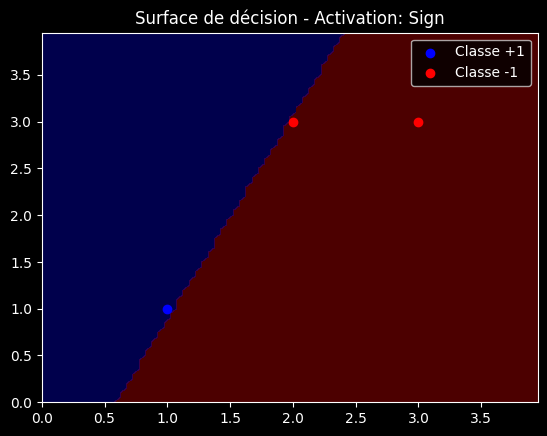

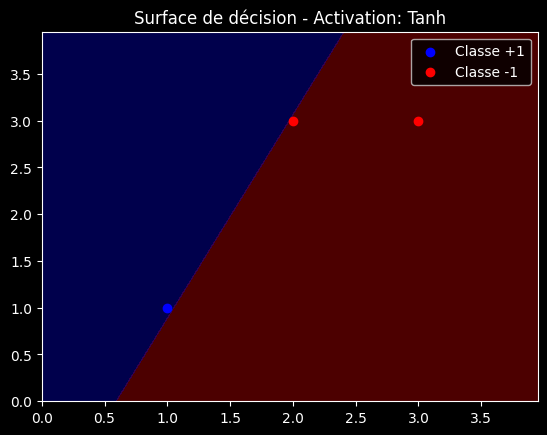

In [4]:
X = np.array([
    [1, 1],
    [2, 3],
    [3, 3]
], dtype=np.float32)
Y = np.array([1, -1, -1], dtype=np.float32)
n_samples, n_features = X.shape

def run_model(activation_type, label, mode):
    model, _ = train_predict_model(lib, X, Y, activation_id=activation_type, mode=mode)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    Z = np.zeros(len(grid_points), dtype=np.float32)
    lib.predict_linear(
        model,
        grid_points.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
        len(grid_points),
        X.shape[1],
        Z.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
    )
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["red", "blue"])
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], color="blue", label="Classe +1")
    plt.scatter(X[Y == -1, 0], X[Y == -1, 1], color="red", label="Classe -1")
    plt.legend()
    plt.title(f"Surface de décision - Activation: {label}")
    plt.show()

    lib.destroy_linear(model)


run_model(2, "Sign", "linear")
run_model(1, "Tanh","linear")





### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

Point 0: Vérité=0, Prédit=0
Point 1: Vérité=0, Prédit=0
Point 2: Vérité=0, Prédit=0
Point 3: Vérité=0, Prédit=0
Point 4: Vérité=0, Prédit=0
Point 5: Vérité=0, Prédit=0
Point 6: Vérité=0, Prédit=0
Point 7: Vérité=0, Prédit=0
Point 8: Vérité=0, Prédit=0
Point 9: Vérité=0, Prédit=0
Point 10: Vérité=0, Prédit=0
Point 11: Vérité=0, Prédit=0
Point 12: Vérité=0, Prédit=0
Point 13: Vérité=0, Prédit=0
Point 14: Vérité=0, Prédit=0
Point 15: Vérité=0, Prédit=0
Point 16: Vérité=0, Prédit=0
Point 17: Vérité=0, Prédit=0
Point 18: Vérité=0, Prédit=0
Point 19: Vérité=0, Prédit=0
Point 20: Vérité=0, Prédit=0
Point 21: Vérité=0, Prédit=0
Point 22: Vérité=0, Prédit=0
Point 23: Vérité=0, Prédit=0
Point 24: Vérité=0, Prédit=0
Point 25: Vérité=0, Prédit=0
Point 26: Vérité=0, Prédit=0
Point 27: Vérité=0, Prédit=0
Point 28: Vérité=0, Prédit=0
Point 29: Vérité=0, Prédit=0
Point 30: Vérité=0, Prédit=0
Point 31: Vérité=0, Prédit=0
Point 32: Vérité=0, Prédit=0
Point 33: Vérité=0, Prédit=0
Point 34: Vérité=0, Préd

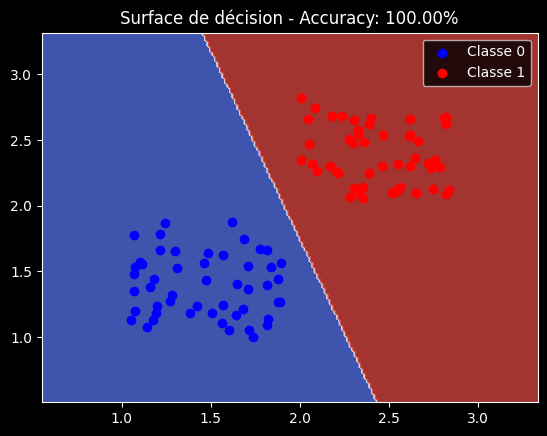

In [16]:
X = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
]).astype(np.float32)

Y = np.concatenate([
    np.zeros((50,), dtype=np.uint32),
    np.ones((50,), dtype=np.uint32)
])
n_classes = 2

model, Y_pred = train_predict_model(lib, X, Y, activation_id=2, mode="multiclass", n_classes=n_classes)

# Accuracy
accuracy = (Y_pred == Y).mean() * 100
for i in range(len(Y)):
    print(f"Point {i}: Vérité={Y[i]}, Prédit={Y_pred[i]}")
print(f"Précision sur les données d'entraînement : {accuracy:.2f}%")

# Grille
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# Prédire sur la grille
Z = np.zeros(len(grid), dtype=np.uint32)
lib.predict_multiclass(
    model,
    grid.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(grid),
    X.shape[1],
    Z.ctypes.data_as(ctypes.POINTER(ctypes.c_uint))
)
Z = Z.reshape(xx.shape)

# Visualisation
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X[:50, 0], X[:50, 1], color="blue", label="Classe 0")
plt.scatter(X[50:, 0], X[50:, 1], color="red", label="Classe 1")
plt.legend()
plt.title(f"Surface de décision - Accuracy: {accuracy:.2f}%")
plt.show()

# Libération mémoire
lib.destroy_multiclass(model)


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [6]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

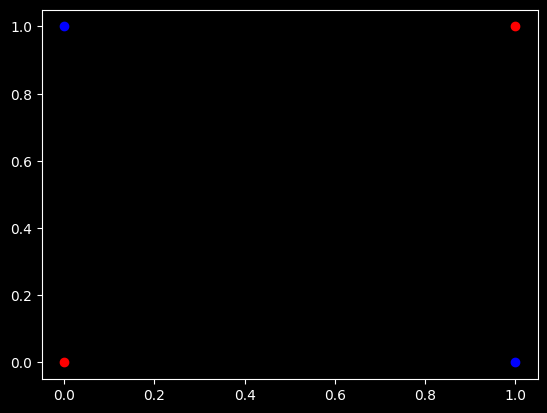

<Figure size 640x480 with 0 Axes>

In [7]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [8]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

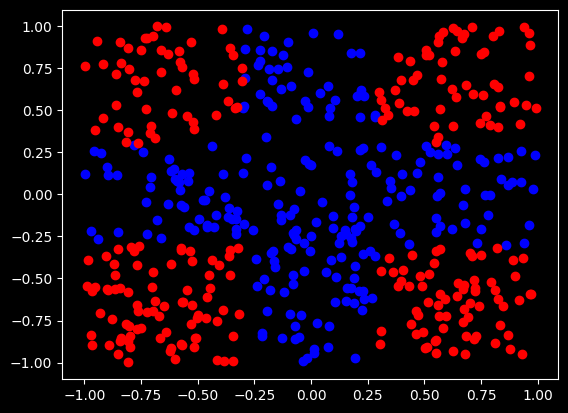

<Figure size 640x480 with 0 Axes>

In [9]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

Précision : 100.00%


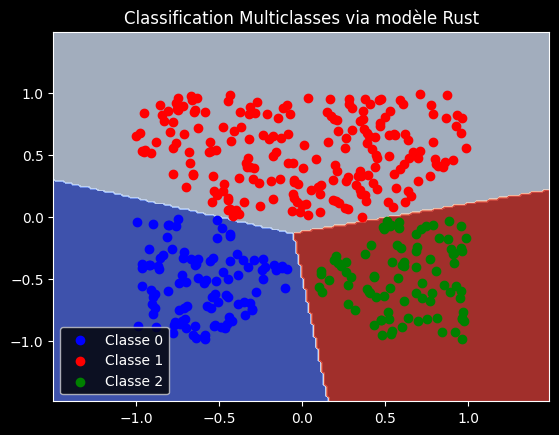

In [10]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
    [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
    [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
    [0, 0, 0]
    for p in X
])

mask = ~np.all(Y == [0, 0, 0], axis=1)
X = X[mask].astype(np.float32)
Y = Y[mask]
Y_idx = np.argmax(Y, axis=1).astype(np.uint32)

from typing import Tuple

def train_predict_model(lib, X: np.ndarray, Y: np.ndarray,
                        activation_id: int = 3,
                        learning_rate: float = 0.1,
                        epochs: int = 1000,
                        verbose: bool = True,
                        mode: str = "linear",
                        n_classes: int = None) -> Tuple[ctypes.c_void_p, np.ndarray]:
    n_samples, n_features = X.shape
    X = X.astype(np.float32)

    if mode == "linear":
        Y = Y.astype(np.float32)
        model = lib.create_linear(n_features, learning_rate, epochs, activation_id)
        lib.train_linear(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            verbose
        )
        Y_pred = np.zeros(n_samples, dtype=np.float32)
        lib.predict_linear(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            Y_pred.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
        )
    elif mode == "multiclass":
        if n_classes is None:
            raise ValueError("n_classes doit être fourni pour mode='multiclass'")
        Y = Y.astype(np.uint32)
        model = lib.create_multiclass(n_classes, n_features, learning_rate, epochs, activation_id)
        lib.train_multiclass(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            Y.ctypes.data_as(ctypes.POINTER(ctypes.c_uint)),
            n_samples,
            n_features,
            verbose
        )
        Y_pred = np.zeros(n_samples, dtype=np.uint32)
        lib.predict_multiclass(
            model,
            X.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
            n_samples,
            n_features,
            Y_pred.ctypes.data_as(ctypes.POINTER(ctypes.c_uint))
        )
    else:
        raise ValueError("mode doit être 'linear' ou 'multiclass'.")
    return model, Y_pred

n_classes = 3
model, Y_pred = train_predict_model(
    lib,
    X,
    Y_idx,
    activation_id=2,
    learning_rate=0.1,
    epochs=1000,
    verbose=True,
    mode="multiclass",
    n_classes=n_classes
)

accuracy = (Y_pred == Y_idx).mean() * 100
print(f"Précision : {accuracy:.2f}%")

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

Z = np.zeros(len(grid), dtype=np.uint32)
lib.predict_multiclass(
    model,
    grid.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(grid),
    X.shape[1],
    Z.ctypes.data_as(ctypes.POINTER(ctypes.c_uint))
)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
colors = ["blue", "red", "green"]
for i in range(n_classes):
    plt.scatter(X[Y_idx == i, 0], X[Y_idx == i, 1], color=colors[i], label=f"Classe {i}")
plt.legend()
plt.title("Classification Multiclasses via modèle Rust")
plt.show()

lib.destroy_multiclass(model)

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

Prédictions : [1. 1.]


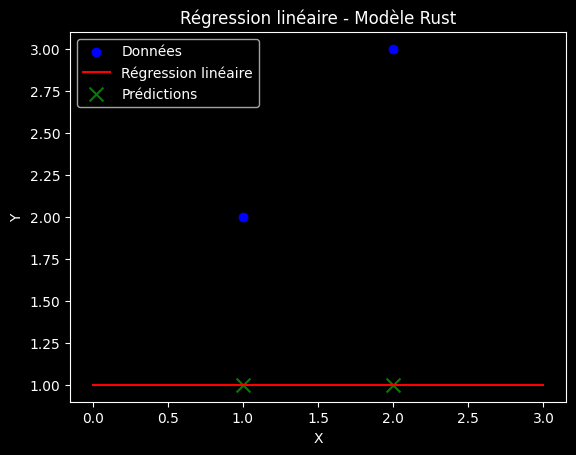

1

In [11]:
X = np.array([[1], [2]], dtype=np.float32)
Y = np.array([2, 3], dtype=np.float32)

model, out = train_predict_model(
    lib,
    X,
    Y,
    activation_id=3,
    learning_rate=0.1,
    epochs=1000,
    verbose=True,
    mode="linear"
)

print("Prédictions :", out)

x_plot = np.linspace(X.min()-1, X.max()+1, 100).astype(np.float32).reshape(-1, 1)
y_plot = np.zeros(len(x_plot), dtype=np.float32)
lib.predict_linear(
    model,
    x_plot.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(x_plot),
    X.shape[1],
    y_plot.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
)

plt.scatter(X, Y, color="blue", label="Données")
plt.plot(x_plot, y_plot, color="red", label="Régression linéaire")
plt.scatter(X, out, color="green", marker="x", s=100, label="Prédictions")
plt.legend()
plt.title("Régression linéaire - Modèle Rust")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

lib.destroy_linear(model)

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

Prédictions : [1. 1. 1.]


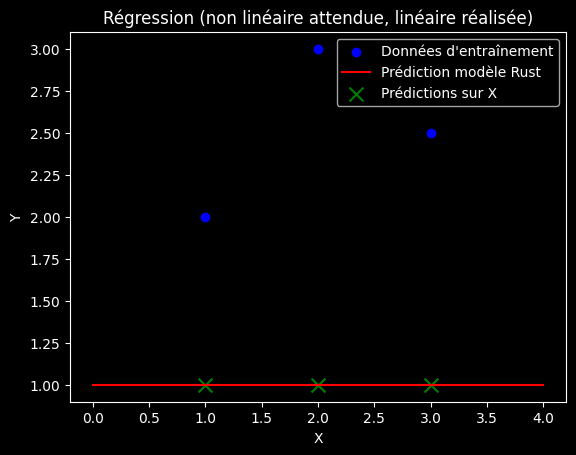

1

In [12]:
X = np.array([[1], [2], [3]], dtype=np.float32)
Y = np.array([2, 3, 2.5], dtype=np.float32)

model, out = train_predict_model(
    lib,
    X,
    Y,
    activation_id=3,
    learning_rate=0.1,
    epochs=1000,
    verbose=True,
    mode="linear"
)

print("Prédictions :", out)

# Prédiction continue pour la droite
x_plot = np.linspace(X.min()-1, X.max()+1, 100).astype(np.float32).reshape(-1, 1)
y_plot = np.zeros(len(x_plot), dtype=np.float32)
lib.predict_linear(
    model,
    x_plot.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(x_plot),
    X.shape[1],
    y_plot.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
)

# Affichage
plt.scatter(X, Y, color="blue", label="Données d'entraînement")
plt.plot(x_plot, y_plot, color="red", label="Prédiction modèle Rust")
plt.scatter(X, out, color="green", marker="x", s=100, label="Prédictions sur X")
plt.legend()
plt.title("Régression (non linéaire attendue, linéaire réalisée)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

lib.destroy_linear(model)

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

Prédictions sur points d'entraînement : [1. 1. 1.]


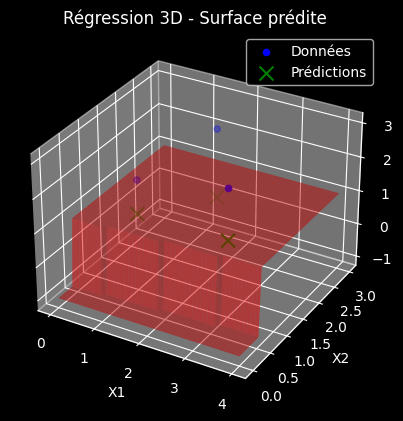

1

In [13]:
X = np.array([
    [1, 1],
    [2, 2],
    [3, 1]
], dtype=np.float32)
Y = np.array([2, 3, 2.5], dtype=np.float32)

# Entraînement via fonction commune
model, out = train_predict_model(
    lib,
    X,
    Y,
    activation_id=3,
    learning_rate=0.01,
    epochs=10000,
    verbose=True,
    mode="linear"
)

print("Prédictions sur points d'entraînement :", out)

# Grille pour prédiction surface
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 50)
x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 50)
xx1, xx2 = np.meshgrid(x1, x2)
grid_points = np.c_[xx1.ravel(), xx2.ravel()].astype(np.float32)

# Prédictions sur la grille
y_grid = np.zeros(len(grid_points), dtype=np.float32)
lib.predict_linear(
    model,
    grid_points.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(grid_points),
    X.shape[1],
    y_grid.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
)
y_grid = y_grid.reshape(xx1.shape)

# Affichage 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y, color="blue", label="Données")
ax.scatter(X[:, 0], X[:, 1], out, color="green", marker="x", s=100, label="Prédictions")
ax.plot_surface(xx1, xx2, y_grid, color="red", alpha=0.5)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.set_title("Régression 3D - Surface prédite")
ax.legend()

plt.show()

lib.destroy_linear(model)

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

Prédictions : [1. 1. 1.]


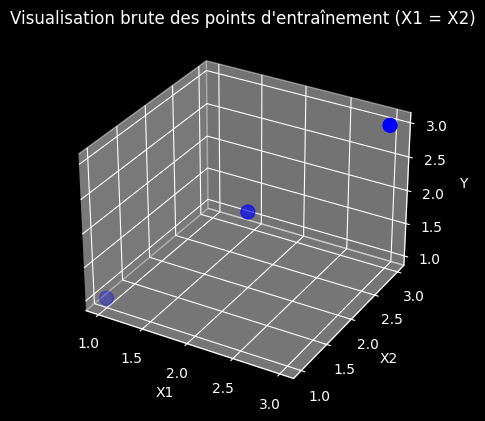

1

In [14]:
X = np.array([
    [1, 1],
    [2, 2],
    [3, 3]
], dtype=np.float32)
Y = np.array([1, 2, 3], dtype=np.float32)

# Entraînement
model, out = train_predict_model(
    lib,
    X,
    Y,
    activation_id=3,
    learning_rate=0.01,
    epochs=10000,
    verbose=True,
    mode="linear"
)

print("Prédictions :", out)

# Génération de la grille pour surface
x1 = np.linspace(0, 4, 50)
x2 = np.linspace(0, 4, 50)
xx1, xx2 = np.meshgrid(x1, x2)
grid = np.c_[xx1.ravel(), xx2.ravel()].astype(np.float32)

# Prédiction sur la grille
y_grid = np.zeros(len(grid), dtype=np.float32)
lib.predict_linear(
    model,
    grid.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
    len(grid),
    X.shape[1],
    y_grid.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
)
y_grid = y_grid.reshape(xx1.shape)


fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], Y, color='blue', s=100)
ax2.set_xlabel("X1")
ax2.set_ylabel("X2")
ax2.set_zlabel("Y")
ax2.set_title("Visualisation brute des points d'entraînement (X1 = X2)")
plt.show()

lib.destroy_linear(model)


### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

Prédictions sur X transformé : [ 1.  1. -1. -1.]


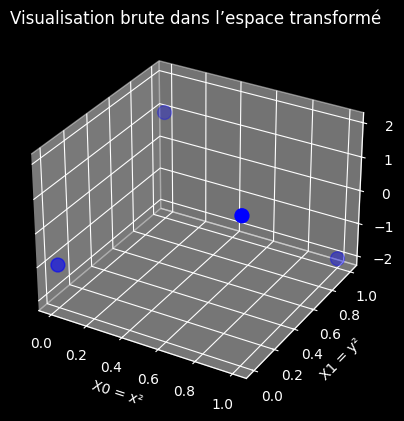

1

<Figure size 640x480 with 0 Axes>

In [15]:
X_raw = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
    [0, 0],
], dtype=np.float32)

Y = np.array([2, 1, -2, -1], dtype=np.float32)

X = np.array([
    [x[0]**2, x[1]**2, x[0] * x[1]] for x in X_raw
], dtype=np.float32)

model, out = train_predict_model(
    lib,
    X,
    Y,
    activation_id=3,         # activation regression linéaire
    learning_rate=0.1,
    epochs=1000,
    verbose=True,
    mode="linear"
)

print("Prédictions sur X transformé :", out)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y, color='blue', s=100)
ax.set_xlabel("X0 = x²")
ax.set_ylabel("X1 = y²")
ax.set_zlabel("Y")
ax.set_title("Visualisation brute dans l’espace transformé")
plt.show()
plt.clf()

lib.destroy_linear(model)